2. clean and preprocess social media text dataset and identify trending topics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("lab2.csv")

In [3]:
data.head()

,post_id,post_text,event_type,timestamp
0,1,Excited for the annual cultural fest this week...,cultural_fest,10-02-2025 14:23
1,2,Cultural Fest 2025 opening ceremony drew a hug...,cultural_fest,10-02-2025 09:05
2,3,Flash mob on the quad kicked off the cultural ...,cultural_fest,09-02-2025 16:40
3,4,Music night at the amphitheatre with bands and...,cultural_fest,10-02-2025 19:30
4,5,Food stalls and art exhibits added color to th...,cultural_fest,10-02-2025 12:10


In [4]:
data.post_text.head(15)

0     Excited for the annual cultural fest this week...
1     Cultural Fest 2025 opening ceremony drew a hug...
2     Flash mob on the quad kicked off the cultural ...
3     Music night at the amphitheatre with bands and...
4     Food stalls and art exhibits added color to th...
5     Dance finals tonight dont miss the cultural sh...
6     Cultural parade with traditional attire was sp...
7     Closing ceremony of the cultural fest with DJ ...
8     AI and ML workshop by industry experts with ha...
9      Cloud computing workshop next week limited seats
10    Robotics workshop, build a line follower bot i...
11    Cybersecurity workshop learn basics of ethical...
12    Data Science workshop intro to Python pandas a...
13    UI and UX design workshop wireframes to protot...
14     NLP workshop today cleaning text and word clouds
Name: post_text, dtype: object

In [5]:
punct = ["!",",",".","/"]
stop_words = ["is","from","and","of","the", "for"]

post = data.post_text.str.lower()
cleaned_text=[]
for text in post:
    for p in punct:
        text=text.replace(p," ")
    splited_text = text.split()
    words = [w for w in splited_text if w not in stop_words]
    cleaned_text.append(" ".join(words))

In [6]:
data["post_text"] = pd.DataFrame(cleaned_text)

In [7]:
data.post_text.head(25)

0     excited annual cultural fest this weekend #mit...
1     cultural fest 2025 opening ceremony drew a hug...
2     flash mob on quad kicked off cultural celebrat...
3     music night at amphitheatre with bands solo pe...
4          food stalls art exhibits added color to fest
5      dance finals tonight dont miss cultural showdown
6     cultural parade with traditional attire was sp...
7          closing ceremony cultural fest with dj night
8     ai ml workshop by industry experts with hands ...
9      cloud computing workshop next week limited seats
10    robotics workshop build a line follower bot in...
11    cybersecurity workshop learn basics ethical ha...
12    data science workshop intro to python pandas p...
13    ui ux design workshop wireframes to prototypes...
14         nlp workshop today cleaning text word clouds
15            workshop q a session with mentors at 5 pm
16              coding hackathon tomorrow register fast
17    ai hackathon this friday build your best i

In [8]:
# Concatenates all rows of the post_text column into a single string separated by spaces, then tokenizes that string into a list of words by splitting on any whitespace.
all_words = " ".join(data.post_text).split()

In [9]:
all_words[:25]

['excited',
 'annual',
 'cultural',
 'fest',
 'this',
 'weekend',
 '#mitfest',
 'cultural',
 'fest',
 '2025',
 'opening',
 'ceremony',
 'drew',
 'a',
 'huge',
 'crowd',
 'flash',
 'mob',
 'on',
 'quad',
 'kicked',
 'off',
 'cultural',
 'celebrations',
 'music']

In [14]:
from collections import Counter
word_count = Counter(all_words)
print("Top 10 popular words are: \n")
for text,count in word_count.most_common(10):
    print(f" {text}: {count}")

Top 10 popular words are: 

 workshop: 8
 cultural: 6
 with: 6
 hackathon: 5
 fest: 4
 a: 4
 to: 4
 annual: 2
 this: 2
 ceremony: 2


In [15]:
print("Event Counts:\n",data["event_type"].value_counts())

Event Counts:
 event_type
cultural_fest    8
workshop         8
hackathon        5
sports_event     3
Name: count, dtype: int64


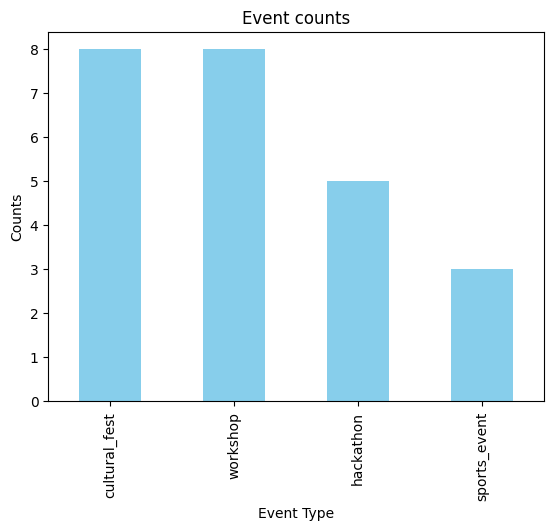

In [16]:
data["event_type"].value_counts().plot(kind="bar",
            color="skyblue")
plt.title("Event counts")
plt.xlabel("Event Type")
plt.ylabel("Counts")
plt.show()